<a href="https://colab.research.google.com/github/gkambasta/TimeSeries/blob/main/Random_Walk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

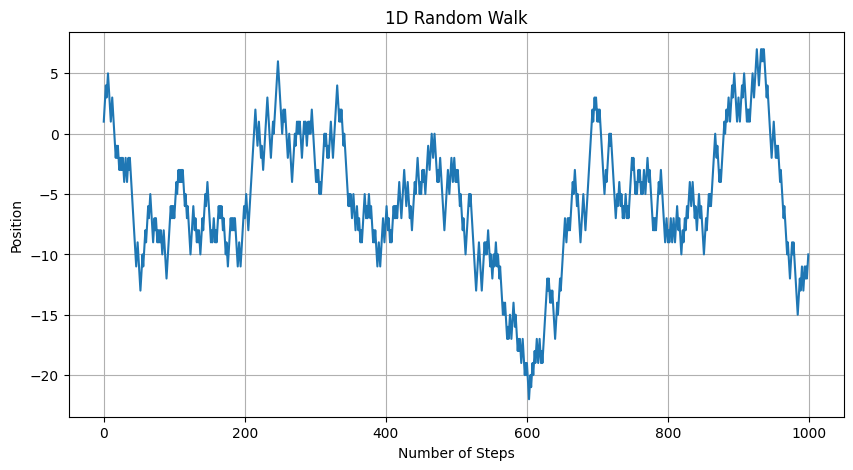

In [10]:

import numpy as np
import matplotlib.pyplot as plt

def random_walk_1d(n_steps):
    # Randomly choose steps: -1 or 1
    steps = np.random.choice([-1, 1], size=n_steps)
    # Calculate position as the cumulative sum of steps
    path = np.cumsum(steps)
    return path

# Simulation
steps = 1000
path = random_walk_1d(steps)

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(path)
plt.title("1D Random Walk")
plt.xlabel("Number of Steps")
plt.ylabel("Position")
plt.grid(True)
plt.show()

### 1D Random Walk Visualization with Seaborn

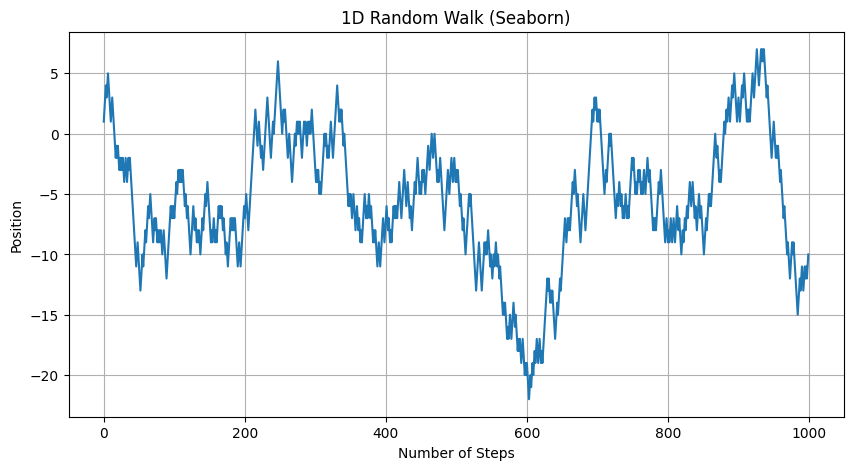

In [11]:
import seaborn as sns

plt.figure(figsize=(10, 5))
sns.lineplot(x=range(len(path)), y=path)
plt.title("1D Random Walk (Seaborn)")
plt.xlabel("Number of Steps")
plt.ylabel("Position")
plt.grid(True)
plt.show()

### 1D Random Walk Visualization with Plotly

In [13]:
import plotly.graph_objects as go

# The 'path' variable for the 1D random walk is already available from previous execution

fig = go.Figure(
    data=[
        go.Scatter(
            x=list(range(len(path))),
            y=path,
            mode='lines',
            name='1D Random Walk Path',
            line=dict(color='purple', width=1)
        )
    ],
    layout=go.Layout(
        title=go.layout.Title(text="1D Random Walk (Plotly)"),
        xaxis=dict(title='Number of Steps'),
        yaxis=dict(title='Position'),
        showlegend=False
    )
)

fig.show()

### Simulating a Stationary Time Series (AR(1) Process)

A stationary time series is one whose statistical properties (like mean, variance, and autocorrelation) do not change over time. A common way to simulate a stationary series is using an Autoregressive (AR) process. Here, we'll simulate an AR(1) process, where the current value depends linearly on its own previous value plus a random error term.

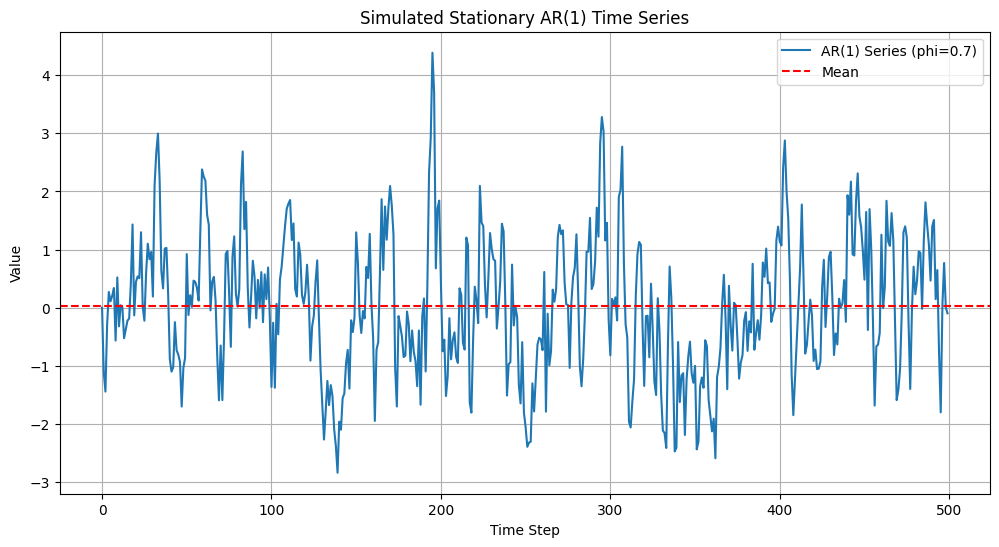

In [15]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_ar1_series(n_steps, phi=0.5, sigma=1.0):
    """
    Simulates a stationary AR(1) time series.

    Args:
        n_steps (int): The number of steps/observations in the series.
        phi (float): The autoregressive coefficient. For stationarity, |phi| < 1.
        sigma (float): The standard deviation of the white noise error term.

    Returns:
        numpy.ndarray: The simulated AR(1) time series.
    """
    # Initialize the series with a starting value (e.g., 0)
    series = np.zeros(n_steps)
    # Generate white noise errors
    errors = np.random.normal(loc=0, scale=sigma, size=n_steps)

    # Simulate the AR(1) process: Xt = phi * Xt-1 + Et
    for i in range(1, n_steps):
        series[i] = phi * series[i-1] + errors[i]

    return series

# Simulation parameters
n_observations = 500
phi_coefficient = 0.7  # For stationarity, |phi| < 1
noise_std = 0.8

# Simulate the stationary AR(1) series
stationary_series = simulate_ar1_series(n_observations, phi=phi_coefficient, sigma=noise_std)

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(stationary_series, label=f'AR(1) Series (phi={phi_coefficient})')
plt.title("Simulated Stationary AR(1) Time Series")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.axhline(np.mean(stationary_series), color='red', linestyle='--', label='Mean')
plt.grid(True)
plt.legend()
plt.show()

### Simulating a Non-Stationary Time Series (Random Walk with Drift)

A non-stationary time series is one whose statistical properties (like mean, variance, or autocorrelation) change over time. A classic example is a random walk with a drift, where the series tends to move in a particular direction over time.

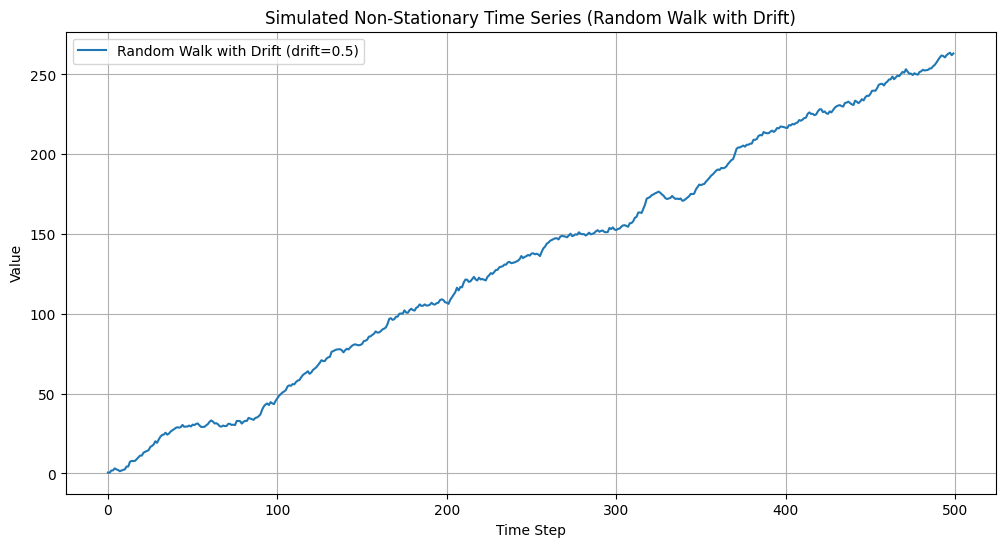

In [17]:
import numpy as np
import matplotlib.pyplot as plt

def simulate_random_walk_with_drift(n_steps, drift=0.1, sigma=1.0):
    """
    Simulates a non-stationary random walk with a drift.

    Args:
        n_steps (int): The number of steps/observations in the series.
        drift (float): The constant value added at each step (the 'drift').
        sigma (float): The standard deviation of the random noise.

    Returns:
        numpy.ndarray: The simulated random walk with drift series.
    """
    # Generate random steps from a normal distribution
    steps = np.random.normal(loc=drift, scale=sigma, size=n_steps)
    # Calculate the path as the cumulative sum of steps
    series = np.cumsum(steps)
    return series

# Simulation parameters
n_observations_non_stationary = 500
drift_value = 0.5  # Positive drift
noise_std_non_stationary = 1.0

# Simulate the non-stationary series
non_stationary_series = simulate_random_walk_with_drift(n_observations_non_stationary, drift=drift_value, sigma=noise_std_non_stationary)

# Visualization
plt.figure(figsize=(12, 6))
plt.plot(non_stationary_series, label=f'Random Walk with Drift (drift={drift_value})')
plt.title("Simulated Non-Stationary Time Series (Random Walk with Drift)")
plt.xlabel("Time Step")
plt.ylabel("Value")
plt.grid(True)
plt.legend()
plt.show()

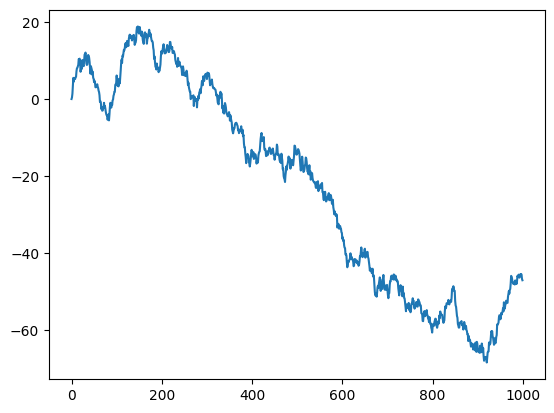

In [26]:
np.random.seed(0)
steps = np.random.standard_normal(1000)
steps[0] = 0
random_walk = np.cumsum(steps)
plt.plot(random_walk)

### ***With Drift***

In [42]:
C=.15
step2 = []

for i in range(len(steps)):
    if i == 0:
        step2.append(steps[i])
    else:
        step2.append(steps[i]+ C)



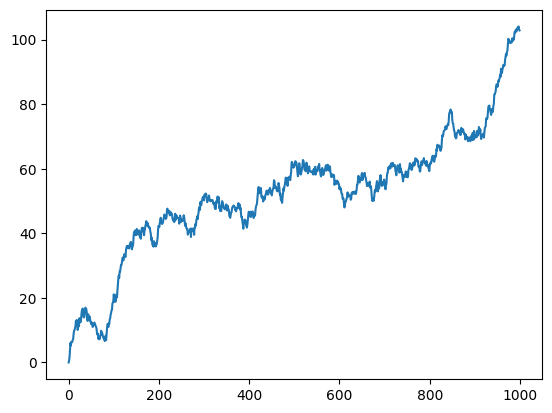

In [43]:
rand2 = np.cumsum(step2)
plt.plot(rand2)
